# Credit card Default Predictions

In [ ]:
# Setup: import core libraries used throughout EDA, preprocessing and modelling (Tasks 1-4)
#Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display_html

sns.set_theme(style="whitegrid")

In [ ]:
# Preliminary load of the raw dataset (separate from the formal Task 2 pipeline below) - used only to build a cleaned copy for Task 1 EDA
df = pd.read_csv("credit_card.csv",sep=";")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'credit_card.csv'

In [ ]:
# Task 1 prerequisite: inspect structure and missing values before starting EDA
#check the dataset 
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34788 entries, 0 to 34787
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          34788 non-null  int64  
 1   LIMIT_BAL                   33079 non-null  float64
 2   SEX                         33021 non-null  float64
 3   EDUCATION                   33054 non-null  float64
 4   MARRIAGE                    33055 non-null  float64
 5   AGE                         33033 non-null  float64
 6   PAY_0                       34788 non-null  int64  
 7   PAY_2                       34788 non-null  int64  
 8   PAY_3                       34788 non-null  int64  
 9   PAY_4                       34788 non-null  int64  
 10  PAY_5                       34788 non-null  int64  
 11  PAY_6                       34788 non-null  int64  
 12  BILL_AMT1                   34788 non-null  float64
 13  BILL_AMT2                   347

ID                               0
LIMIT_BAL                     1709
SEX                           1767
EDUCATION                     1734
MARRIAGE                      1733
AGE                           1755
PAY_0                            0
PAY_2                            0
PAY_3                            0
PAY_4                            0
PAY_5                            0
PAY_6                            0
BILL_AMT1                        0
BILL_AMT2                        0
BILL_AMT3                        0
BILL_AMT4                        0
BILL_AMT5                        0
BILL_AMT6                        0
PAY_AMT1                      1725
PAY_AMT2                      1744
PAY_AMT3                         0
PAY_AMT4                         0
PAY_AMT5                         0
PAY_AMT6                         0
default.payment.next.month       0
risk_leak                        0
BILL_AMT_SUM                     0
LIMIT_BAL_LOG                 1709
CITY                

In [ ]:
# Supports Task 2.1: summarise missing values (count + %) per column
#check missing numerical values
missing_table = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_table = missing_table[
    missing_table["Missing Values"] > 0
]

missing_table = missing_table.sort_values(
    "Missing Percentage",
    ascending=False
)

print("\nMissing Value Summary:")
display(missing_table)


Missing Value Summary:


,Missing Values,Missing Percentage
SEX,1767,5.079338
AGE,1755,5.044843
PAY_AMT2,1744,5.013223
EDUCATION,1734,4.984477
MARRIAGE,1733,4.981603
PAY_AMT1,1725,4.958606
LIMIT_BAL,1709,4.912614
LIMIT_BAL_LOG,1709,4.912614


In [ ]:
# Preliminary cleaning (EDA copy only): drop rows with missing target - a missing label can't be imputed or used for training
#Data Cleaning
target = "default.payment.next.month"

df = df.dropna(
    subset=[target]
).copy()

In [ ]:
# Preliminary cleaning (EDA copy only): impute missing categorical values with the mode
#Create categorical variables
categorical_features = [
    "SEX",
    "EDUCATION",
    "MARRIAGE",
    "CITY",
    "RISK_RATING"
]

categorical_features = [
    col
    for col in categorical_features
    if col in df.columns
]

for col in categorical_features: #fill missing categorical values

    if df[col].isna().any():
        mode_values = df[col].mode(dropna=True)
        if not mode_values.empty:
            df[col] = df[col].fillna(
                mode_values.iloc[0]
            )

In [ ]:
# Preliminary cleaning (EDA copy only): impute missing numeric values with the median
#create numerical variables 
numerical_columns = [
    col
    for col in df.select_dtypes(include=np.number).columns
    if col != target
    and col not in categorical_features
]

for col in numerical_columns:

    if df[col].isna().any():

        df[col] = df[col].fillna(
            df[col].median()
        )

LIMIT_BAL_LOG in the original file is stored as object.
Therefore, recreate it directly from LIMIT_BAL.

In [ ]:
# Data quality fix: LIMIT_BAL_LOG was stored as text/object in the source file, so it is recomputed directly from LIMIT_BAL
if "LIMIT_BAL" in df.columns:

    df["LIMIT_BAL"] = pd.to_numeric(df["LIMIT_BAL"],errors="coerce")

    if df["LIMIT_BAL"].isna().any():
        df["LIMIT_BAL"] = df["LIMIT_BAL"].fillna(df["LIMIT_BAL"].median())

    df["LIMIT_BAL_LOG"] = np.log1p(df["LIMIT_BAL"])

In [ ]:
# Data quality check: confirm risk_leak is fully numeric before using it in EDA statistics/plots
# CHECK risk_leak COLUMN

if "risk_leak" in df.columns:

    risk_numeric = pd.to_numeric(df["risk_leak"],errors="coerce")
    conversion_rate = (risk_numeric.notna().mean() * 100)

    if risk_numeric.notna().all():
        df["risk_leak"] = risk_numeric
    else:
        print(
            f"\nWarning: risk_leak contains mixed/malformed values.\n"
            f"Only {conversion_rate:.2f}% of values converted directly "
            f"to numeric.\n"
            f"risk_leak will therefore be excluded from numerical "
            f"statistics and plots."
        )


Only 90.26% of values converted directly to numeric.
risk_leak will therefore be excluded from numerical statistics and plots.


In [ ]:
# Confirm no missing values remain in this EDA working copy of df
#check missing values after cleaning

print("\nMissing Values After Cleaning:")
print(
    df.isnull()
    .sum()
    .sort_values(ascending=False)
    .head(10)
)


Missing Values After Cleaning:
ID           0
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
dtype: int64


# Task 1 : Exploratory Data Analysis (EDA) 


Task 1.1 : Distribution of Target Variable

,Count,Percentage (%)
default.payment.next.month,,
0,28132,80.87
1,6656,19.13


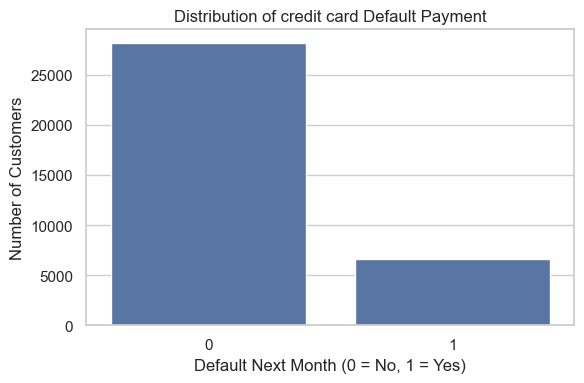

In [ ]:
# Task 1.1: class counts + percentages and a bar chart -> use this to discuss class imbalance in the report
# Count target classes
target_counts = (
    df[target]
    .value_counts()
    .sort_index()
)

# Calculate percentages
target_percentage = (
    df[target]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

# Summary table
target_summary = pd.DataFrame({"Count": target_counts,"Percentage (%)": target_percentage.round(2)})

display(target_summary)

# Target visualization
plt.figure(figsize=(6, 4))
sns.countplot(data=df,x=target)

plt.title("Distribution of credit card Default Payment")
plt.xlabel("Default Next Month (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

Task 1.2 : Discriptive Statistics

In this code we calculate :

Mean,
Median,
Standard deviation,
Minimum,
Maximum,

for variables such as LIMIT_BAL, AGE, BILL_AMT_SUM, and LIMIT_BAL_LOG.

In [ ]:
# Task 1.2: descriptive statistics (mean, median, std, min, max) for LIMIT_BAL, AGE, BILL_AMT_SUM, LIMIT_BAL_LOG, risk_leak
numerical_features = [
    "LIMIT_BAL",
    "AGE",
    "BILL_AMT_SUM",
    "LIMIT_BAL_LOG"
]

# Include risk_leak only when it is numeric
if (
    "risk_leak" in df.columns
    and pd.api.types.is_numeric_dtype(df["risk_leak"])
):
    numerical_features.append("risk_leak")

# Keep only features existing in dataset
numerical_features = [
    col
    for col in numerical_features
    if col in df.columns
]


# Descriptive statistics
descriptive_stats = (
    df[numerical_features]
    .agg([
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
    .T
)
display(descriptive_stats)

,mean,median,std,min,max
LIMIT_BAL,182474.579740,140000.000000,230266.054480,10000.00000,5.600000e+06
AGE,35.441704,34.000000,9.006903,21.00000,7.900000e+01
BILL_AMT_SUM,294815.170892,129037.000000,571807.252079,-336259.00000,2.129266e+07
LIMIT_BAL_LOG,11.705644,11.849405,0.943620,9.21044,1.553828e+01


In [ ]:
# Sanity check: confirm LIMIT_BAL_LOG values are consistent with LIMIT_BAL
# Check LIMIT_BAL_LOG
if {
    "LIMIT_BAL",
    "LIMIT_BAL_LOG"
}.issubset(df.columns):

    print(
        "LIMIT_BAL_LOG Data Type:",
        df["LIMIT_BAL_LOG"].dtype
    )

    print(
        "LIMIT_BAL_LOG Missing Values:",
        df["LIMIT_BAL_LOG"].isna().sum()
    )
    display(df[["LIMIT_BAL","LIMIT_BAL_LOG"]].head(10))

LIMIT_BAL_LOG Data Type: float64
LIMIT_BAL_LOG Missing Values: 0


,LIMIT_BAL,LIMIT_BAL_LOG
0,20000.0,9.903538
1,120000.0,11.695255
2,90000.0,11.407576
3,50000.0,10.819798
4,50000.0,10.819798
5,50000.0,10.819798
6,140000.0,11.849405
7,100000.0,11.512935
8,140000.0,11.849405
9,20000.0,9.903538


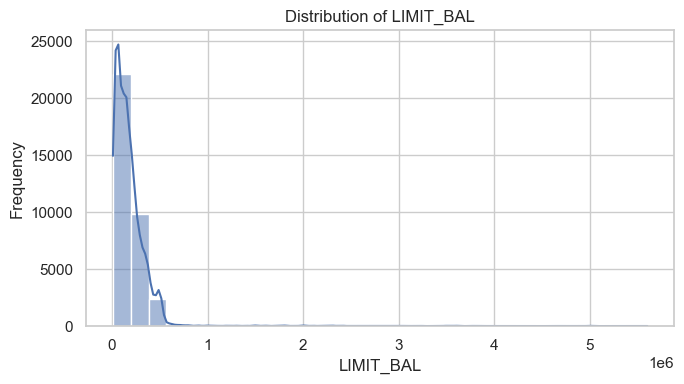

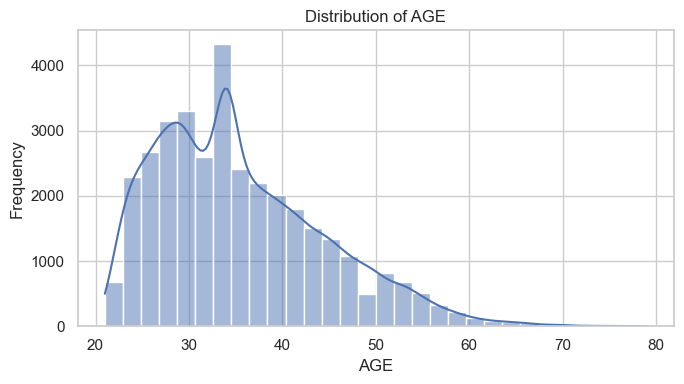

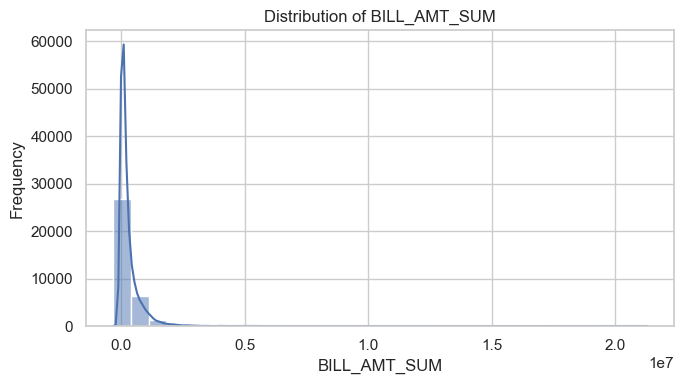

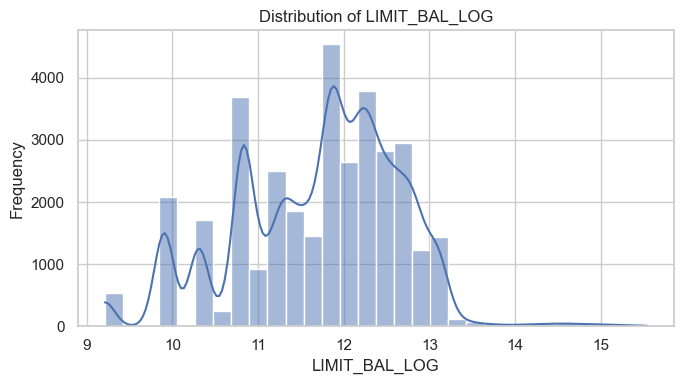

In [ ]:
# Task 1.3: histograms for numerical features -> identify skewness and spread
#Histograms of all descriptive statistics
for column in numerical_features:

    plt.figure(figsize=(7, 4))
    sns.histplot(
        data=df,
        x=column,
        bins=30,
        kde=True
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

Task 1.4 : Box Plots

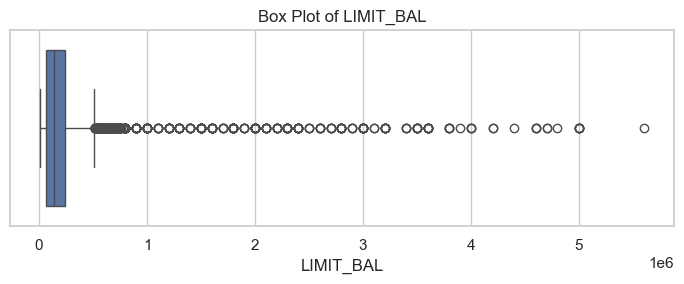

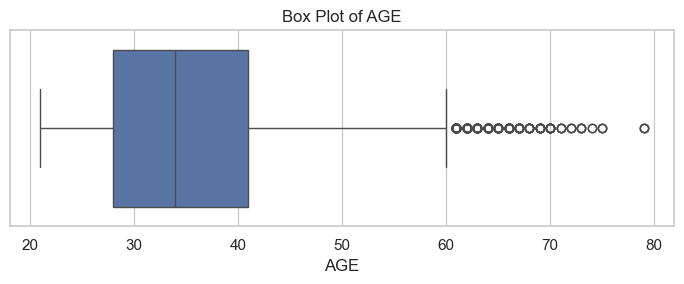

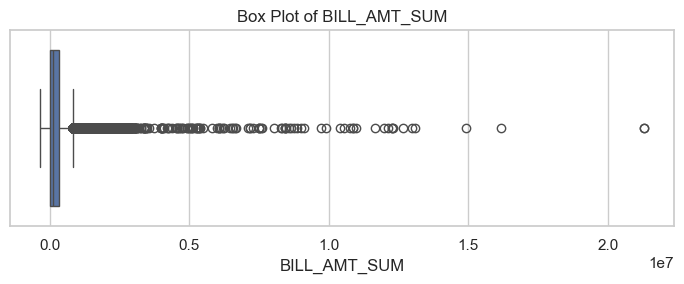

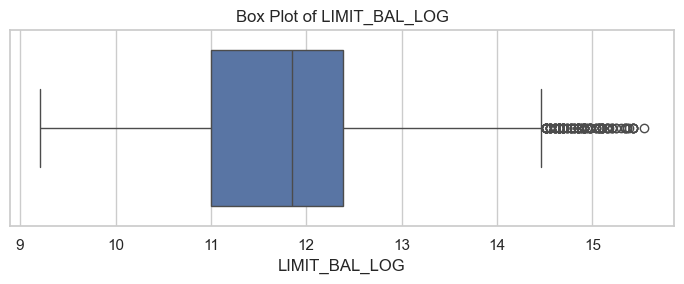

In [ ]:
# Task 1.4: box plots for numerical features -> identify outliers
for column in numerical_features:

    plt.figure(figsize=(7, 3))

    sns.boxplot(
        data=df,
        x=column
    )

    plt.title(f"Box Plot of {column}")
    plt.xlabel(column)
    plt.tight_layout()
    plt.show()

Task 1.5 = Categorical Features

As per assignment we have to find counts and percentage in this feature.

In [ ]:
# Task 1.5: value counts for categorical features (SEX, EDUCATION, MARRIAGE, CITY, RISK_RATING)
#finding a counts 

count_tables = []
for column in categorical_features:
    table = (
        df[column]
        .value_counts(dropna=False)
        .head(5)
        .to_frame("Count")
    )

    html = f"""
    <div style="
        display:inline-block;
        vertical-align:top;
    ">
        {table.to_html()}
    </div>
    """
    count_tables.append(html)

display_html(
    "".join(count_tables),
    raw=True
)

,Count
SEX,
2.0,21720
1.0,13068
,Count
EDUCATION,
2.0,17126
1.0,11724
3.0,5421
5.0,306
4.0,140


In [ ]:
# Task 1.5: percentage distribution of categorical features
#finding a Percentage
percentage_tables = []

for column in categorical_features:

    percentages = (
        df[column]
        .value_counts(
            normalize=True,
            dropna=False
        )
        .mul(100)
        .head(5)
        .round(2)
        .to_frame(
            "Percentage (%)"
        )
    )

    html = f"""
    <div style="
        display:inline-block;
        vertical-align:top;
    ">
        {percentages.to_html()}
    </div>
    """
    percentage_tables.append(html)

display_html(
    "".join(percentage_tables),
    raw=True
)

,Percentage (%)
SEX,
2.0,62.44
1.0,37.56
,Percentage (%)
EDUCATION,
2.0,49.23
1.0,33.70
3.0,15.58
5.0,0.88
4.0,0.40


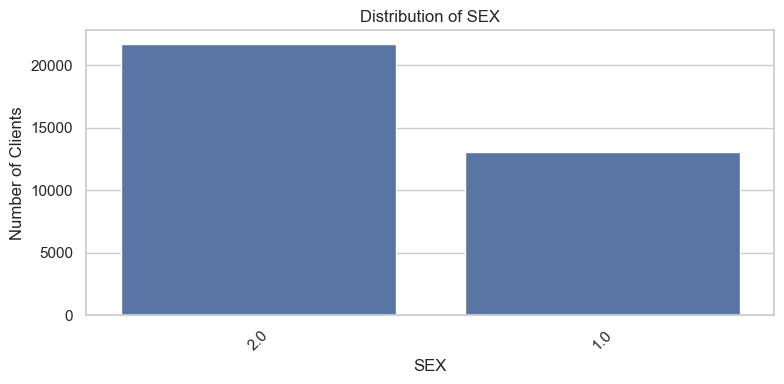

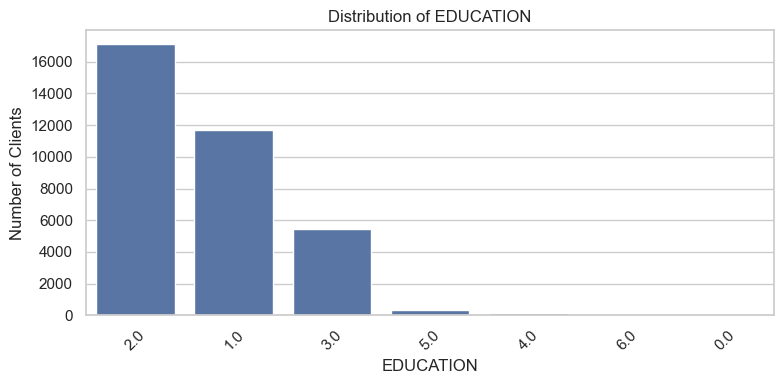

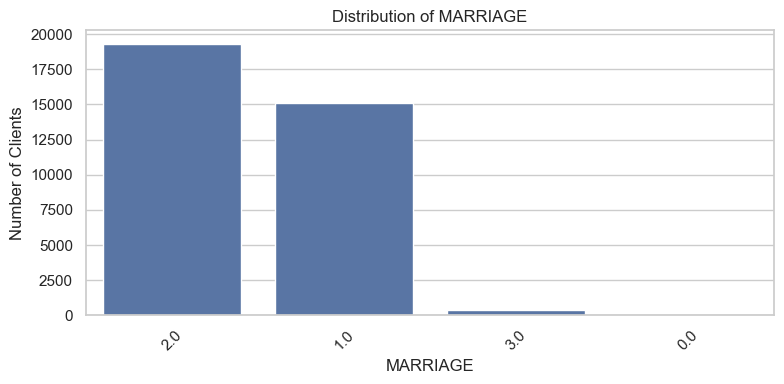

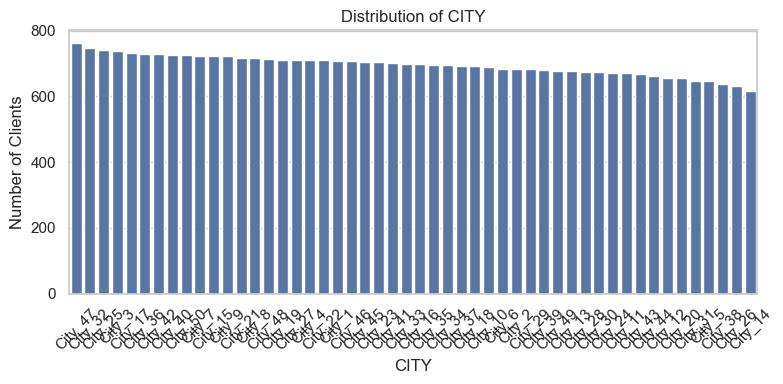

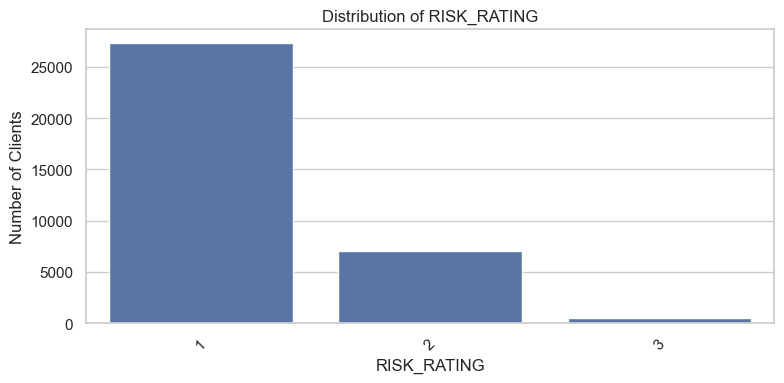

In [ ]:
# Task 1.5: bar charts of categorical feature distributions
 # Counts in visualization
for column in categorical_features:

    plt.figure(figsize=(8, 4))

    order = (
        df[column]
        .value_counts()
        .index
    )

    sns.countplot(
        data=df,
        x=column,
        order=order
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Clients")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Task 1.6 : Default Rate by category

In [ ]:
# Task 1.6: default rate (%) by category, top 5 values per feature
# NOTE (QA): 'html = ...' and 'default_rate_tables.append(html)' below are NOT indented inside the for-loop,
# so only the LAST feature processed (RISK_RATING) is actually appended and displayed.
# If you want every categorical feature's table shown side-by-side (like the counts/percentages above),
# indent those two lines so they run inside the loop.
default_rate_tables = []

for column in categorical_features:

    default_rate = (
        df.groupby(
            column,
            dropna=False
        )[target]
        .mean()
        .mul(100)
        .sort_values(
            ascending=False
        )
        .head(5)
        .round(2)
        .to_frame(
            "Default Rate (%)"
        )
    )
html = f"""
    <div style="
        display:inline-block;
        vertical-align:top;
    ">
        {default_rate.to_html()}
    </div>
    """

default_rate_tables.append(html)
display_html("".join(default_rate_tables),raw=True)

,Default Rate (%)
RISK_RATING,
3,68.10
2,44.36
1,11.79


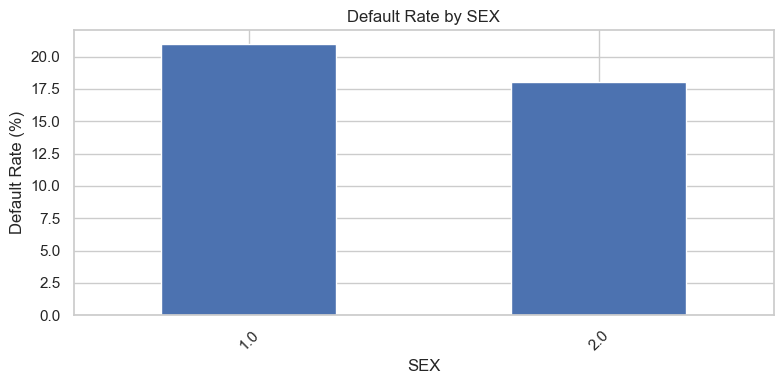

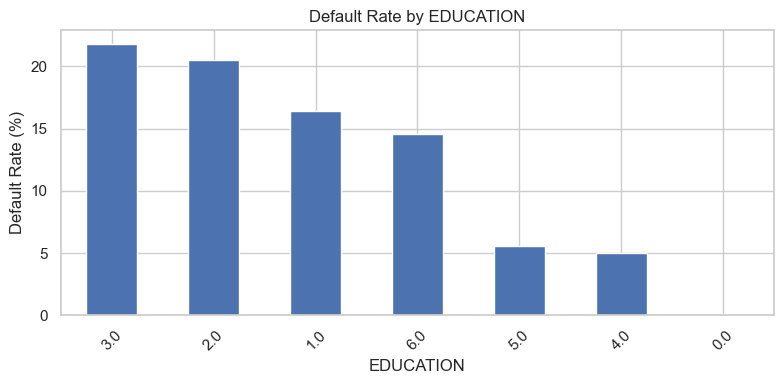

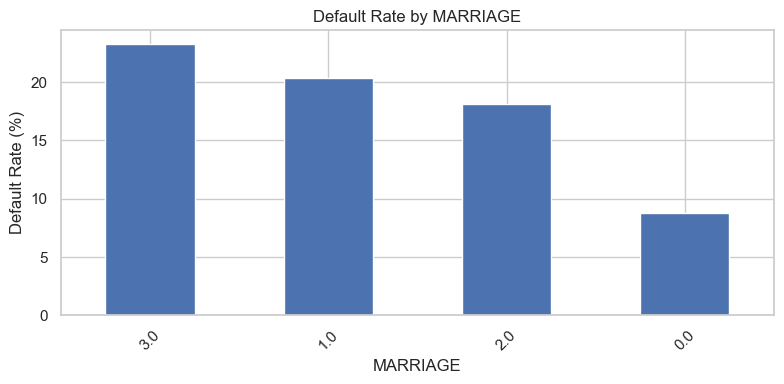

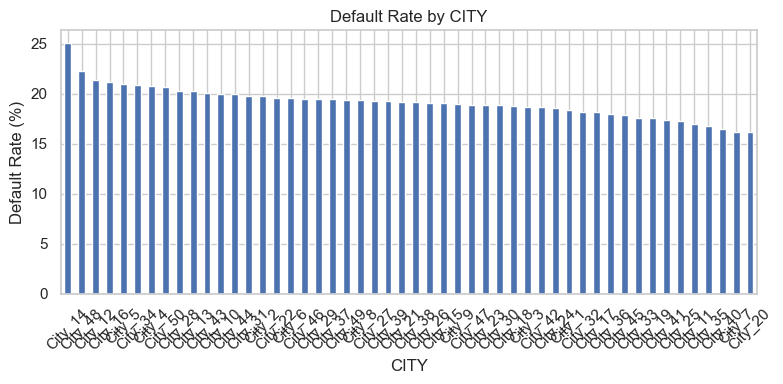

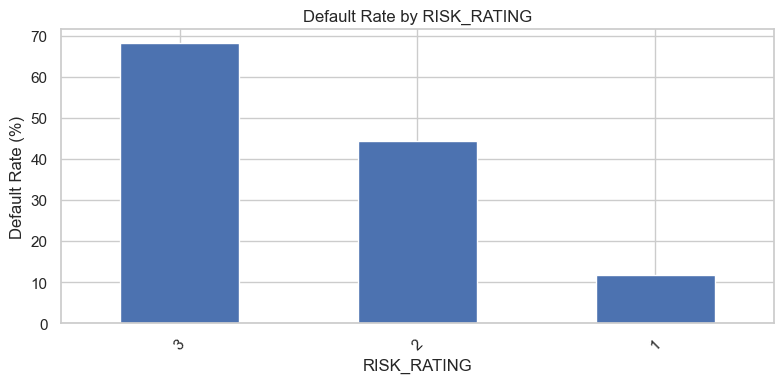

In [ ]:
# Task 1.6: default-rate bar chart per category (separate, correctly-indented loop - one chart per feature)
# Default rate visualization

for column in categorical_features:

    default_rate = (
        df.groupby(
            column,
            dropna=False
        )[target]
        .mean()
        .mul(100)
        .sort_values(
            ascending=False
        )
    )

    plt.figure(figsize=(8, 4))

    default_rate.plot(kind="bar")

    plt.title(f"Default Rate by {column}")
    plt.ylabel("Default Rate (%)")
    plt.xlabel(column)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Task 1.7 : correlations between numerical features and the target variable

In [ ]:
# Task 1.7: correlation of numeric features with the target, sorted by absolute strength
numeric_df = df.select_dtypes(
    include=np.number
)

correlations = (
    numeric_df
    .corr(numeric_only=True)[target]
    .drop(target)
    .sort_values(
        key=abs,
        ascending=False
    )
)

display(
    correlations.to_frame("Correlation with Default"))

,Correlation with Default
RISK_RATING,0.362487
PAY_0,0.314230
PAY_2,0.253757
PAY_3,0.224862
PAY_4,0.207571
PAY_5,0.196277
PAY_6,0.179303
LIMIT_BAL_LOG,-0.156832
LIMIT_BAL,-0.087402
PAY_AMT1,-0.067381


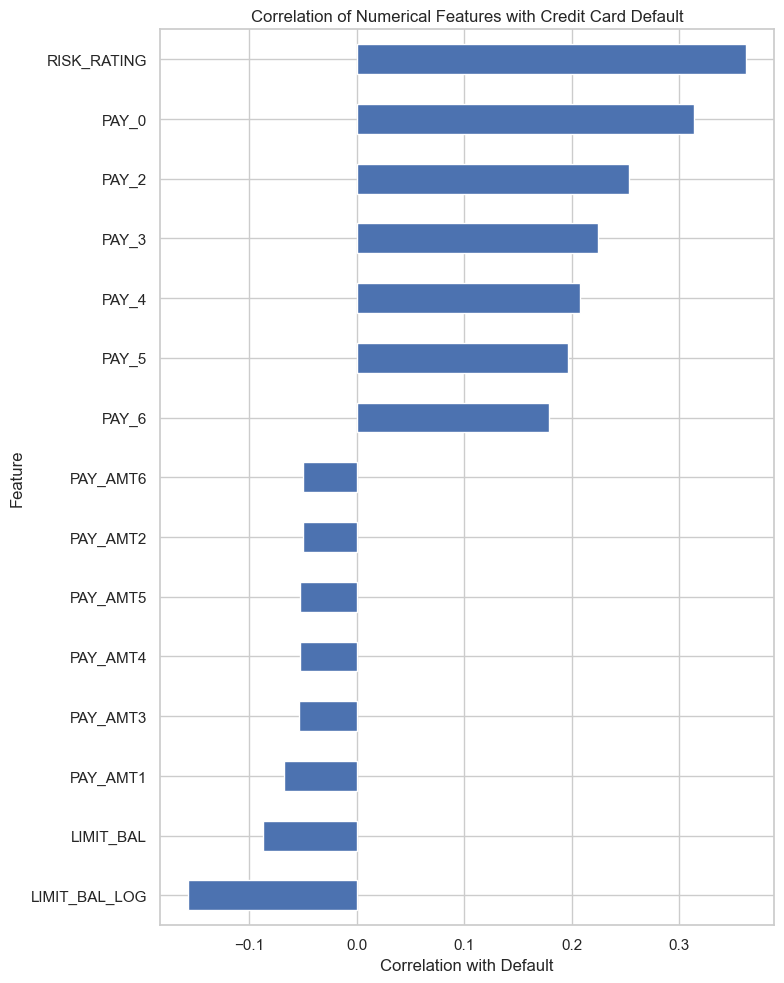

In [ ]:
# Task 1.7: visualise the top 15 numeric features most correlated with default
#corelation visualization

plt.figure(
    figsize=(8, 10)
)

correlations.head(15) \
    .sort_values() \
    .plot(
        kind="barh"
    )

plt.title("Correlation of Numerical Features with Credit Card Default")
plt.xlabel("Correlation with Default")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Task 1.8 : CHECK PAY_0 TO PAY_6

In [ ]:
# Task 1.8: define the PAY_0-PAY_6 repayment-history columns
payment_features = [
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6"
]

# Keep only available columns
payment_features = [
    col
    for col in payment_features
    if col in df.columns
]

In [ ]:
# Task 1.8: correlation of PAY_0-PAY_6 with default
#clorelation between payment satuts and default

payment_correlations = (
    df[
        payment_features
        + [target]
    ]
    .corr(numeric_only=True)[target]
    .drop(target)
    .sort_values(
        ascending=False
    )
)

display(
    payment_correlations.to_frame(
        "Correlation with Default"
    )
)


,Correlation with Default
PAY_0,0.314230
PAY_2,0.253757
PAY_3,0.224862
PAY_4,0.207571
PAY_5,0.196277
PAY_6,0.179303


In [ ]:
# Task 1.8: default rate (%) at each repayment-status value, per PAY column
#Default Rate for each repayment-status value 
for column in payment_features:

    default_rate = (
        df.groupby(column)[target]
        .mean()
        .mul(100)
        .sort_index()
    )

    payment_default_rates = pd.DataFrame(default_rate).T
    display(payment_default_rates.round(2))


PAY_0,-2,-1,0,1,2,3,4,5,6,7,8
default.payment.next.month,11.23,14.36,10.9,30.23,65.14,71.98,65.0,43.33,50.0,77.78,57.89


PAY_2,-2,-1,0,1,2,3,4,5,6,7,8
default.payment.next.month,15.73,13.67,13.6,16.13,51.13,56.74,44.64,55.56,75.0,60.0,0.0


PAY_3,-2,-1,0,1,2,3,4,5,6,7,8
default.payment.next.month,15.98,13.33,14.99,20.0,46.69,52.87,53.66,50.0,58.33,81.48,50.0


PAY_4,-2,-1,0,1,2,3,4,5,6,7,8
default.payment.next.month,16.61,13.58,15.76,50.0,47.6,56.12,63.01,50.0,33.33,78.69,33.33


PAY_5,-2,-1,0,2,3,4,5,6,7,8
default.payment.next.month,17.02,13.81,16.23,49.41,60.96,56.67,55.56,50.0,80.0,100.0


PAY_6,-2,-1,0,2,3,4,5,6,7,8
default.payment.next.month,17.33,14.53,16.2,46.03,61.78,56.36,41.18,63.64,82.61,100.0


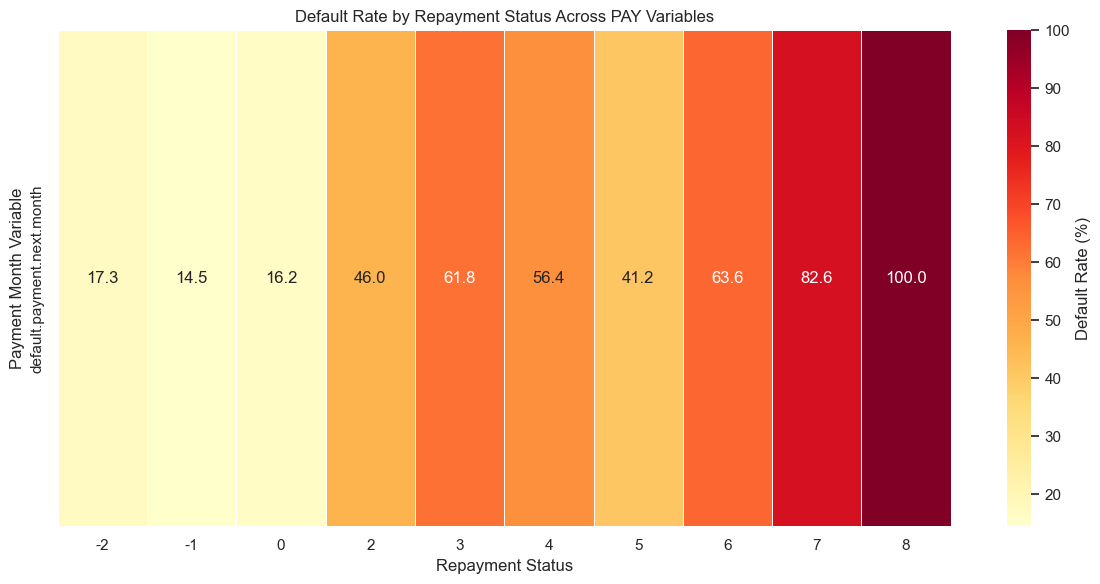

In [ ]:
# Task 1.8: heatmap of default rate by repayment status across PAY_0-PAY_6
plt.figure(figsize=(12, 6))

sns.heatmap(
    payment_default_rates,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={
        "label": "Default Rate (%)"
    }
)

plt.title("Default Rate by Repayment Status Across PAY Variables")
plt.xlabel("Repayment Status")
plt.ylabel("Payment Month Variable")
plt.tight_layout()
plt.show()

# Task 2 : Data Preparation

In this phase, we intend to prepare the dataset for machine learning modelling.
This involves dealing with missing values, encoding categorical values, scaling numeric values, 
and analyzing the dataset before and after preprocessing.

It should be noted that a great deal of consideration has gone into the design 
of the preprocessing procedure to avoid data leakage issues.

Task 2.1 : Identify Missing Values

In [ ]:
# Task 2.1: reload the RAW dataset again (separate from the cleaned EDA copy above) so the formal preprocessing pipeline starts from untouched data
df = pd.read_csv("Credit_Card.csv",sep=";")

print("Dataset shape:", df.shape)
print(df.head())
print(df.columns.tolist())
print(df.info())

Dataset shape: (34788, 30)
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE   AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1    20000.0  2.0        2.0       NaN  24.0      2      2     -1     -1   
1   2   120000.0  2.0        2.0       2.0  26.0     -1      2      0      0   
2   3    90000.0  2.0        2.0       2.0  34.0      0      0      0      0   
3   4    50000.0  2.0        2.0       1.0  37.0      0      0      0      0   
4   5    50000.0  1.0        2.0       1.0  57.0     -1      0     -1      0   

   ...  PAY_AMT3  PAY_AMT4  PAY_AMT5  PAY_AMT6  default.payment.next.month  \
0  ...       0.0       0.0       0.0       0.0                           1   
1  ...    1000.0    1000.0       0.0    2000.0                           1   
2  ...    1000.0    1000.0    1000.0    5000.0                           0   
3  ...    1200.0    1100.0    1069.0    1000.0                           0   
4  ...   10000.0    9000.0     689.0     679.0                           0   

                risk_le

C:\Users\parth\AppData\Local\Temp\ipykernel_15408\65334712.py:2: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Credit_Card.csv",sep=";")


In [ ]:
# Task 2.1: identify all missing values (count + %) per column - the formal record to justify handling method in the report
# check missing values and percentage in every columns
missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_count,
    "Missing Percentage (%)": missing_percentage.round(2)
})

missing_summary = missing_summary[
    missing_summary["Missing Values"] > 0
].sort_values(
    by="Missing Values",
    ascending=False
)

display(missing_summary)

,Missing Values,Missing Percentage (%)
SEX,1767,5.08
AGE,1755,5.04
PAY_AMT2,1744,5.01
EDUCATION,1734,4.98
MARRIAGE,1733,4.98
PAY_AMT1,1725,4.96
LIMIT_BAL,1709,4.91
LIMIT_BAL_LOG,1709,4.91


In [ ]:
# Task 2.1: overall missing-value footprint (total missing cells, rows affected, % of rows affected)
total_missing = df.isnull().sum().sum()

print("Total number of missing values:",total_missing)

rows_with_missing = df.isnull().any(axis=1).sum()

print("Rows containing at least one missing value:",rows_with_missing)

missing_rows_percentage = (rows_with_missing / len(df)) * 100

print("Percentage of rows containing missing values:",round(missing_rows_percentage, 2),"%")

Total number of missing values: 13876
Rows containing at least one missing value: 10491
Percentage of rows containing missing values: 30.16 %


In [ ]:
# Task 2.1 (extra QA, not explicitly required but useful for the report): check for duplicate rows
duplicate_count = df.duplicated().sum() # duplicate check
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 2858


In [ ]:
# Task 2.1: dtype + missing count for columns that still have missing values -> use to justify imputation vs. row removal per column
#check columns with missing values
data_quality_summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Unique Values": df.nunique(),
    "Missing Values": df.isnull().sum()
})

data_quality_summary = data_quality_summary[
    data_quality_summary["Missing Values"] > 0
]

display(data_quality_summary)

,Data Type,Unique Values,Missing Values
LIMIT_BAL,float64,117,1709
SEX,float64,2,1767
EDUCATION,float64,7,1734
MARRIAGE,float64,4,1733
AGE,float64,56,1755
PAY_AMT1,float64,7716,1725
PAY_AMT2,float64,7655,1744
LIMIT_BAL_LOG,object,81,1709


In [ ]:
# Task 2: drop the non-predictive ID column before modelling
model_df = df.copy()

if "ID" in model_df.columns:
    model_df = model_df.drop(columns=["ID"])

    print("ID column removed from modelling.")
else:
    print("No ID column was found.")

ID column removed from modelling.


Task 2.2 :Seprate Predictors and targets

In [ ]:
# Task 2.2: separate predictors (X) and target (y)
X = model_df.drop(columns=["default.payment.next.month"])
y = model_df["default.payment.next.month"]

print("Predictor shape:",X.shape)
print("Target shape:",y.shape)

Predictor shape: (34788, 28)
Target shape: (34788,)


### Task 2.2 : Encode Categorical Variables

In [ ]:
# Task 2.2: define categorical vs numerical feature lists (used for encoding/scaling below)
categorical_features = [
    "SEX",
    "EDUCATION",
    "MARRIAGE",
    "CITY",
    "RISK_RATING"
]

numerical_features = [
    column for column in X.columns
    if column not in categorical_features
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)


Categorical features:
['SEX', 'EDUCATION', 'MARRIAGE', 'CITY', 'RISK_RATING']

Numerical features:
['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'risk_leak', 'BILL_AMT_SUM', 'LIMIT_BAL_LOG']


In [ ]:
# Task 2.2: enforce correct dtypes (categorical -> str, numerical -> float) before encoding/scaling;
# malformed values become NaN and are imputed by the pipeline below
for column in categorical_features:

    # Convert to object first
    X[column] = X[column].astype(object)
    X[column] = X[column].apply(
        lambda value: np.nan if pd.isna(value) else str(value)
    )

for column in numerical_features:

    X[column] = pd.to_numeric(
        X[column],
        errors="coerce"
    ).astype(float)

print("Data types corrected.")


Data types corrected.


In [ ]:
# QA check: confirm key numeric columns converted correctly
print(X[
    [
        "LIMIT_BAL",
        "AGE",
        "BILL_AMT_SUM",
        "risk_leak",
        "LIMIT_BAL_LOG"
    ]
].dtypes)

LIMIT_BAL        float64
AGE              float64
BILL_AMT_SUM     float64
risk_leak        float64
LIMIT_BAL_LOG    float64
dtype: object


In [ ]:
# QA check: cardinality of categorical features (informs the OneHotEncoder choice)
print("Number of unique values in categorical features:\n")

for column in categorical_features:
    print( column, ":",
        X[column].nunique(dropna=True)
    )

Number of unique values in categorical features:

SEX : 2
EDUCATION : 7
MARRIAGE : 4
CITY : 50
RISK_RATING : 3


In [ ]:
# QA check: cardinality of risk_leak / LIMIT_BAL_LOG
print("\nNumber of unique values in selected numerical features:")

print("risk_leak:", X["risk_leak"].nunique())
print("LIMIT_BAL_LOG:", X["LIMIT_BAL_LOG"].nunique())


Number of unique values in selected numerical features:
risk_leak: 26629
LIMIT_BAL_LOG: 0


### Task 2.3 : Scale Numerical Variables (build the preprocessing pipeline)

In [ ]:
# Task 2.3: imports needed to build the preprocessing pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.base import clone


In [ ]:
# Task 2.3: build the preprocessing pipeline - median-impute + StandardScaler for numeric features,
# most-frequent-impute + OneHotEncoder for categorical features
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

print("Preprocessor created successfully.")


Preprocessor created successfully.


### Task 2.4 : Before / After Example

In [ ]:
# Task 2.4: fit a demo copy of the preprocessor to show a before/after example
# (this demo is fit on the full X purely for illustration - the REAL pipeline used for
# modelling in Task 3 is fit only on X_train, inside each model's own Pipeline, to avoid data leakage)
preprocessor_demo = clone(preprocessor)
preprocessor_demo.fit(X)

print("Preprocessor fitted successfully.")


c:\Users\parth\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['LIMIT_BAL_LOG']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Preprocessor fitted successfully.


In [ ]:
# Task 2.4: AFTER-preprocessing example (5 rows) - compare against X.head() BEFORE
X_example = preprocessor_demo.transform(X.head(5))

# Retrieve feature names
feature_names = preprocessor_demo.get_feature_names_out()

# Convert into DataFrame
after_example = pd.DataFrame(
    X_example,
    columns=feature_names,
    index=X.head(5).index
)

print("BEFORE preprocessing:")
display(X.head(5))

print("AFTER preprocessing:")
display(after_example)


BEFORE preprocessing:


c:\Users\parth\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['LIMIT_BAL_LOG']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,risk_leak,BILL_AMT_SUM,LIMIT_BAL_LOG,CITY,RISK_RATING
0,20000.0,2.0,2.0,NaN,24.0,2.0,2.0,-1.0,-1.0,-2.0,...,689.0,0.0,0.0,0.0,0.0,NaN,7704.0,NaN,City_38,2
1,120000.0,2.0,2.0,2.0,26.0,-1.0,2.0,0.0,0.0,0.0,...,1000.0,1000.0,1000.0,0.0,2000.0,NaN,17077.0,NaN,City_6,1
2,90000.0,2.0,2.0,2.0,34.0,0.0,0.0,0.0,0.0,0.0,...,1500.0,1000.0,1000.0,1000.0,5000.0,0.070302,101653.0,NaN,City_20,1
3,50000.0,2.0,2.0,1.0,37.0,0.0,0.0,0.0,0.0,0.0,...,2019.0,1200.0,1100.0,1069.0,1000.0,0.058442,231334.0,NaN,City_25,1
4,50000.0,1.0,2.0,1.0,57.0,-1.0,0.0,-1.0,0.0,0.0,...,36681.0,10000.0,9000.0,689.0,679.0,0.129431,109339.0,NaN,City_44,1


AFTER preprocessing:


,num__LIMIT_BAL,num__AGE,num__PAY_0,num__PAY_2,num__PAY_3,num__PAY_4,num__PAY_5,num__PAY_6,num__BILL_AMT1,num__BILL_AMT2,...,cat__CITY_City_49,cat__CITY_City_5,cat__CITY_City_50,cat__CITY_City_6,cat__CITY_City_7,cat__CITY_City_8,cat__CITY_City_9,cat__RISK_RATING_1,cat__RISK_RATING_2,cat__RISK_RATING_3
0,-0.705605,-1.270344,1.854343,1.831884,-0.689979,-0.660686,-1.539734,-1.494748,-0.645719,-0.649452,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,-0.271319,-1.048289,-0.864912,1.831884,0.157195,0.207583,0.254203,2.035235,-0.662489,-0.668822,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,-0.401605,-0.160069,0.041506,0.133275,0.157195,0.207583,0.254203,0.270243,-0.300709,-0.495772,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,-0.575319,0.173014,0.041506,0.133275,0.157195,0.207583,0.254203,0.270243,-0.058891,-0.014603,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,-0.575319,2.393565,-0.864912,0.133275,-0.689979,0.207583,0.254203,0.270243,-0.581638,-0.613328,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
# Task 2: confirm the imputers leave no missing values after transforming the full predictor set
X_processed_check = preprocessor_demo.transform(X)

print(
    "Missing values after preprocessing:",
    pd.isna(X_processed_check).sum()
)


c:\Users\parth\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['LIMIT_BAL_LOG']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Missing values after preprocessing: 0


# Task 3 : Model Training

**Note:** the dead-end cell that used to sit here (recomputing `LIMIT_BAL_LOG` on `df` instead of `X`/`model_df`) has been removed - it had no effect on the modelling data. `LIMIT_BAL_LOG` is correctly numeric-coerced for `X` in the Task 2.2 dtype-correction step above.

In [ ]:
# Task 3.1: 80/20 stratified train-test split - stratify=y preserves the class-imbalance ratio in both sets.
# Justify the 80/20 ratio in the report given the dataset size (~34.8k rows after cleaning).
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (27830, 28)
Testing set shape: (6958, 28)


In [ ]:
# QA check before fitting the preprocessor
print("Numerical columns:", len(numerical_features))
print("Categorical columns:", len(categorical_features))

print("\nCategorical:")
print(categorical_features)

print("\nCheck important numerical variables:")

for column in [
    "LIMIT_BAL",
    "AGE",
    "BILL_AMT_SUM",
    "LIMIT_BAL_LOG",
    "risk_leak"
]:
    print(column, "->", X_train[column].dtype)

Numerical columns: 23
Categorical columns: 5

Categorical:
['SEX', 'EDUCATION', 'MARRIAGE', 'CITY', 'RISK_RATING']

Check important numerical variables:
LIMIT_BAL -> float64
AGE -> float64
BILL_AMT_SUM -> float64
LIMIT_BAL_LOG -> float64
risk_leak -> float64


In [ ]:
# Task 3.2: imports for the 5 required classification algorithms + helpers
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import joblib
import time


In [ ]:
# Task 3.2: the 5 required classification algorithms, left at default hyperparameters
models = {
    "Logistic Regression":LogisticRegression(),
    "Support Vector Machine": SVC(),
    "Decision Tree":DecisionTreeClassifier(),
    "Random Forest":RandomForestClassifier(),
    "K-Nearest Neighbors":KNeighborsClassifier()
}

print("Models prepared:")
for model_name in models:
    print("-", model_name)

Models prepared:
- Logistic Regression
- Support Vector Machine
- Decision Tree
- Random Forest
- K-Nearest Neighbors


In [ ]:
# Task 3.3: record each model's default hyperparameters BEFORE any tuning (required by the brief)
for model_name, model in models.items():
    
    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)
    
    print(model.get_params())


Logistic Regression
{'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 100, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': None, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}

Support Vector Machine
{'C': 1.0, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'probability': False, 'random_state': None, 'shrinking': True, 'tol': 0.001, 'verbose': False}

Decision Tree
{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'}

Random Forest
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 

In [ ]:
# Task 3.2: fit each model inside its own Pipeline(preprocessor + classifier) on the training set
trained_models = {}
training_times = {}

for model_name, model in models.items():
    print("\n" + "=" * 70)
    print(f"Training: {model_name}")
    print("=" * 70)
    
    # Each model receives its own independent copy
    # of the preprocessing pipeline.
    model_pipeline = Pipeline(
        steps=[("preprocessor",clone(preprocessor)),
                ("classifier",model)])
    
    start_time = time.time()
    model_pipeline.fit(
        X_train,
        y_train
    )
    
    elapsed_time = time.time() - start_time # Calculate training duration
    trained_models[model_name] = model_pipeline # Store trained pipeline
    training_times[model_name] = elapsed_time # Store training time
    
    print(
        f"{model_name} trained successfully "
        f"in {elapsed_time:.2f} seconds."
    )


Training: Logistic Regression


c:\Users\parth\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['LIMIT_BAL_LOG']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Logistic Regression trained successfully in 1.02 seconds.

Training: Support Vector Machine


c:\Users\parth\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['LIMIT_BAL_LOG']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Support Vector Machine trained successfully in 102.38 seconds.

Training: Decision Tree


...

Decision Tree trained successfully in 1.23 seconds.

Training: Random Forest


c:\Users\parth\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['LIMIT_BAL_LOG']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Random Forest trained successfully in 20.66 seconds.

Training: K-Nearest Neighbors


c:\Users\parth\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['LIMIT_BAL_LOG']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


K-Nearest Neighbors trained successfully in 0.43 seconds.


In [ ]:
# Task 3: training time per model - useful discussion point re: dataset size / algorithm complexity
training_summary = pd.DataFrame({
    "Model": training_times.keys(),
    "Training Time (seconds)": training_times.values()
})

training_summary[
    "Training Time (seconds)"
] = training_summary[
    "Training Time (seconds)"
].round(2)

display(training_summary)

,Model,Training Time (seconds)
0,Logistic Regression,1.02
1,Support Vector Machine,102.38
2,Decision Tree,1.23
3,Random Forest,20.66
4,K-Nearest Neighbors,0.43


In [ ]:
# Persist trained pipelines so Task 4 evaluation can be re-run without retraining
joblib.dump(
    trained_models,
    "task3_trained_models.joblib"
)

print("Trained models saved successfully.")

Trained models saved successfully.


In [ ]:
print("Number of models trained:", len(trained_models))

Number of models trained: 5


# Task : 4 Model Evaluation 

In [ ]:
# Task 4: imports for evaluation metrics, confusion matrices, ROC curves and hyperparameter tuning (GridSearchCV/RandomizedSearchCV)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    auc,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    ParameterGrid
)
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
# Task 4.1 helper: get probability/decision scores for ROC-AUC (SVC uses decision_function; the others use predict_proba)
def get_prediction_scores(model, X):

    # Models with predict_proba()
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]

    # Models such as SVM with decision_function()
    elif hasattr(model, "decision_function"):
        return model.decision_function(X)

    else:
        raise ValueError(
            f"{type(model).__name__} does not provide "
            "predict_proba or decision_function."
        )

In [ ]:
# Task 4.1: accuracy, precision, recall, F1-score, ROC-AUC for every trained model on the held-out test set
evaluation_results = []

for model_name, model in trained_models.items():

    # Predictions
    y_pred = model.predict(X_test)

    # Scores for ROC-AUC
    y_score = get_prediction_scores(
        model,
        X_test
    )

    # Evaluation metrics
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_score
    )

    # Store results
    evaluation_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })

print("Evaluation completed successfully.")

c:\Users\parth\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['LIMIT_BAL_LOG']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


c:\Users\parth\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['LIMIT_BAL_LOG']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\parth\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['LIMIT_BAL_LOG']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\parth\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['LIMIT_BAL_LOG']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\parth\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['LIMIT_BAL_LOG']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users

Evaluation completed successfully.


In [ ]:
# Task 4.1/4.2: comparative results table, sorted by ROC-AUC
evaluation_df = pd.DataFrame(evaluation_results)

evaluation_df = evaluation_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

display(
    evaluation_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.9586,0.9860,0.7949,0.8802,0.9984
1,Decision Tree,0.9980,0.9970,0.9925,0.9947,0.9959
2,Logistic Regression,0.8958,0.8750,0.5312,0.6611,0.8714
3,K-Nearest Neighbors,0.9039,0.8552,0.5988,0.7044,0.8568
4,Support Vector Machine,0.9102,0.9468,0.5620,0.7053,0.8289


In [ ]:
# Task 4.2: identify the current best-performing model (pre-tuning) - this is the candidate to hyperparameter-tune next
best_model_name = evaluation_df.iloc[0]["Model"]
best_roc_auc = evaluation_df.iloc[0]["ROC-AUC"]

print("Best model based on ROC-AUC:", best_model_name)
print(f"ROC-AUC: {best_roc_auc:.4f}")

Best model based on ROC-AUC: Random Forest
ROC-AUC: 0.9984


c:\Users\parth\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['LIMIT_BAL_LOG']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


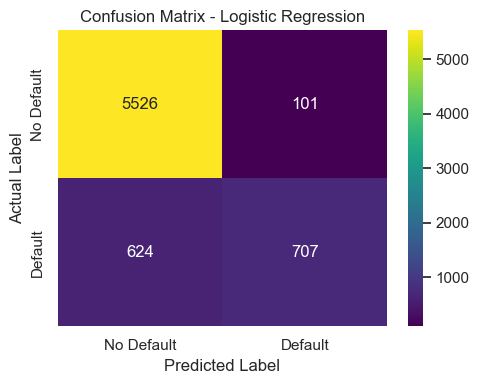

c:\Users\parth\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['LIMIT_BAL_LOG']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


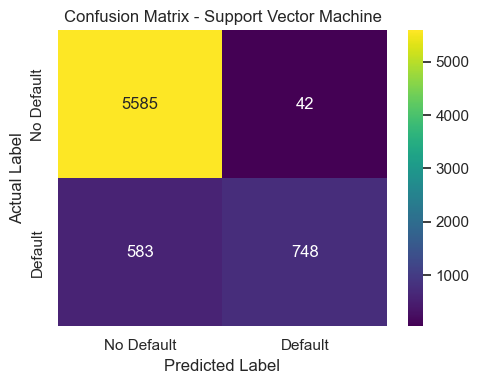

c:\Users\parth\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['LIMIT_BAL_LOG']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


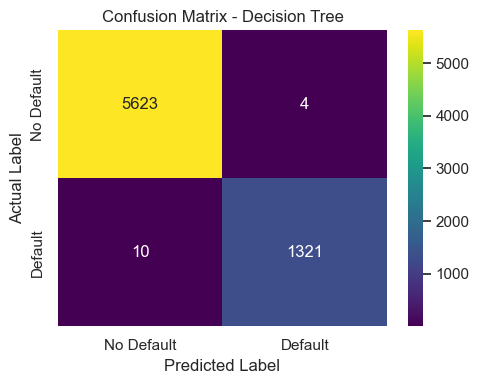

c:\Users\parth\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['LIMIT_BAL_LOG']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


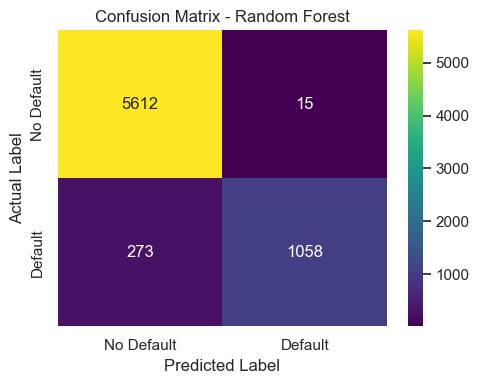

c:\Users\parth\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['LIMIT_BAL_LOG']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


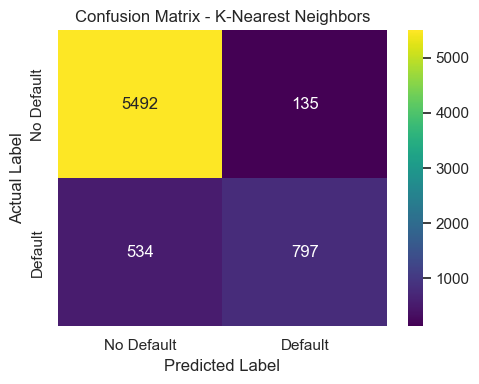

In [ ]:
# Task 4.3: confusion matrix heatmap for each model
for model_name, model in trained_models.items():

    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
       cm,
        annot=True,          # show numbers inside the boxes
        fmt="d",             # show as integers
        cmap="viridis",      # similar style to your screenshot
        cbar=True,           # show color bar
        xticklabels=["No Default", "Default"],
        yticklabels=["No Default", "Default"]
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.tight_layout()
    plt.show()

In [ ]:
# Supports Task 4.1: per-class precision/recall/F1 detail for each model
#classification Report
for model_name, model in trained_models.items():

    print("\n")
    print("=" * 60)

    print(model_name)
    print("=" * 60)

    # Predictions
    y_pred = model.predict(X_test)

    # Display precision, recall and F1-score
    print(
        classification_report(
            y_test,
            y_pred,
            zero_division=0
        )
    )



Logistic Regression


c:\Users\parth\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['LIMIT_BAL_LOG']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.90      0.98      0.94      5627
           1       0.88      0.53      0.66      1331

    accuracy                           0.90      6958
   macro avg       0.89      0.76      0.80      6958
weighted avg       0.89      0.90      0.89      6958



Support Vector Machine


c:\Users\parth\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['LIMIT_BAL_LOG']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.91      0.99      0.95      5627
           1       0.95      0.56      0.71      1331

    accuracy                           0.91      6958
   macro avg       0.93      0.78      0.83      6958
weighted avg       0.91      0.91      0.90      6958



Decision Tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5627
           1       1.00      0.99      0.99      1331

    accuracy                           1.00      6958
   macro avg       1.00      1.00      1.00      6958
weighted avg       1.00      1.00      1.00      6958



Random Forest


c:\Users\parth\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['LIMIT_BAL_LOG']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\parth\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['LIMIT_BAL_LOG']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.95      1.00      0.97      5627
           1       0.99      0.79      0.88      1331

    accuracy                           0.96      6958
   macro avg       0.97      0.90      0.93      6958
weighted avg       0.96      0.96      0.96      6958



K-Nearest Neighbors


c:\Users\parth\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['LIMIT_BAL_LOG']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.91      0.98      0.94      5627
           1       0.86      0.60      0.70      1331

    accuracy                           0.90      6958
   macro avg       0.88      0.79      0.82      6958
weighted avg       0.90      0.90      0.90      6958



c:\Users\parth\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['LIMIT_BAL_LOG']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\parth\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['LIMIT_BAL_LOG']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\parth\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['LIMIT_BAL_LOG']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\parth\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['LIMIT_BAL_LOG']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users

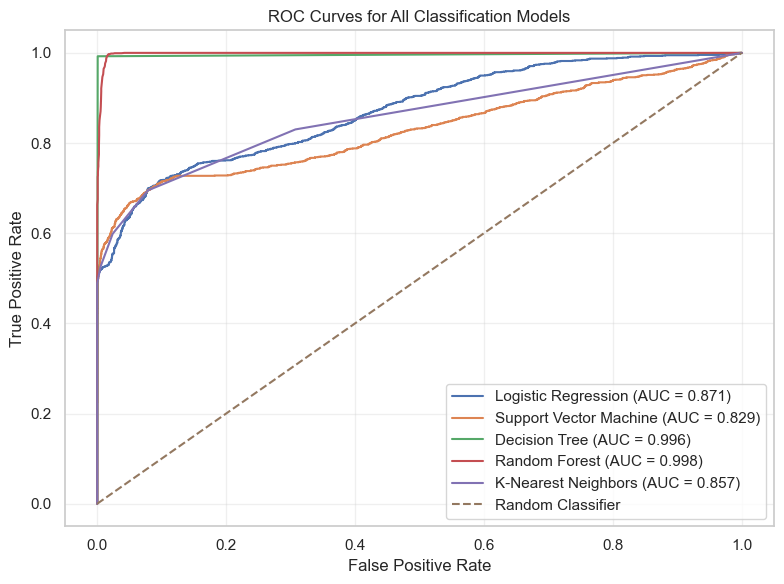

In [ ]:
# Task 4.3: ROC curves for all models on one plot
plt.figure(figsize=(8, 6))

for model_name, model in trained_models.items():
    y_score = get_prediction_scores(model, X_test)
    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_score
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC = {roc_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Classification Models")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

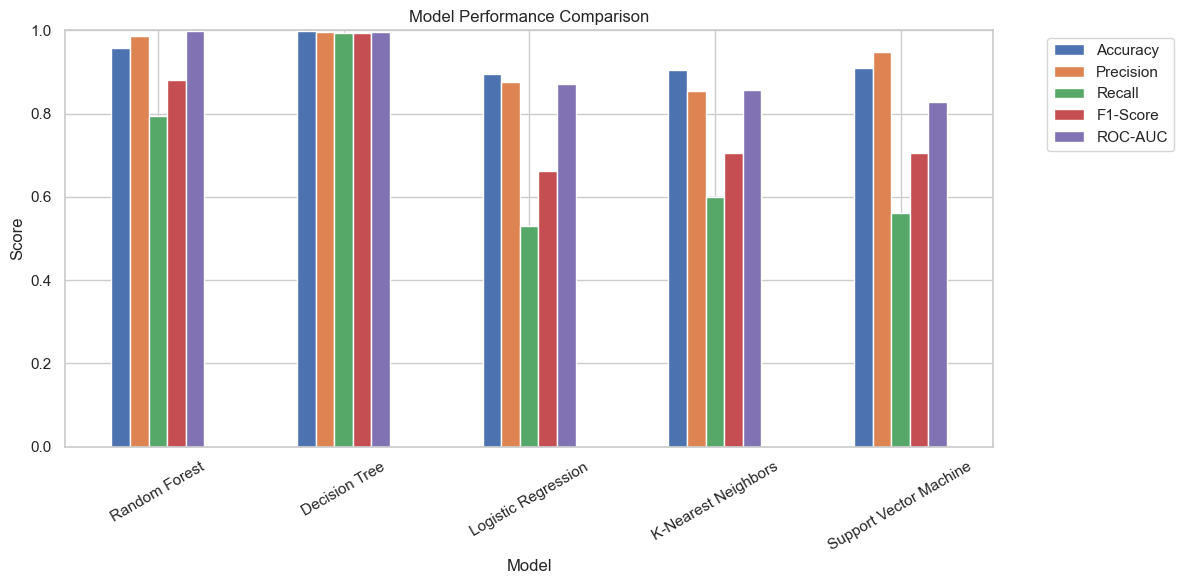

In [ ]:
# Task 4.2: grouped bar chart comparing all 5 metrics across models
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

evaluation_df.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

In [ ]:
# Save the PRE-TUNING results table as 'baseline_results' so it can be compared against the post-tuning results in Task 4.5
baseline_results = evaluation_df.copy()

display(
    baseline_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.9586,0.9860,0.7949,0.8802,0.9984
1,Decision Tree,0.9980,0.9970,0.9925,0.9947,0.9959
2,Logistic Regression,0.8958,0.8750,0.5312,0.6611,0.8714
3,K-Nearest Neighbors,0.9039,0.8552,0.5988,0.7044,0.8568
4,Support Vector Machine,0.9102,0.9468,0.5620,0.7053,0.8289


## Task 4.4 : Hyperparameter Tuning

Tuning the top-performing baseline model(s) with `RandomizedSearchCV` (faster than `GridSearchCV` on ~28k training rows). Add/remove models from `param_distributions` if you want to tune more than one.

In [ ]:
# Task 4.4: hyperparameter tuning for the best baseline model(s)
# NOTE: fill in / adjust which model(s) to tune based on YOUR baseline_results ranking above.

param_distributions = {
    "Random Forest": {
        "classifier__n_estimators": [200, 400, 600],
        "classifier__max_depth": [None, 6, 10, 16],
        "classifier__min_samples_split": [2, 5, 10],
        "classifier__min_samples_leaf": [1, 2, 4],
    },
    "Logistic Regression": {
        "classifier__C": [0.01, 0.1, 1, 10, 100],
        "classifier__penalty": ["l2"],
        "classifier__solver": ["lbfgs"],
    },
    "Decision Tree": {
        "classifier__max_depth": [None, 4, 8, 12, 20],
        "classifier__min_samples_split": [2, 5, 10, 20],
        "classifier__min_samples_leaf": [1, 2, 4, 8],
    },
    "K-Nearest Neighbors": {
        "classifier__n_neighbors": [5, 11, 21, 31, 51],
        "classifier__weights": ["uniform", "distance"],
    },
    "Support Vector Machine": {
        "classifier__C": [0.1, 1, 10],
        "classifier__kernel": ["rbf", "linear"],
        "classifier__gamma": ["scale", "auto"],
    },
}

# Pick which model(s) to tune - default: the single best baseline model by ROC-AUC
models_to_tune = [best_model_name]
# models_to_tune = list(param_distributions.keys())  # <- uncomment to tune all 5 instead

tuned_models = {}
tuning_summary = []

for model_name in models_to_tune:
    if model_name not in param_distributions:
        print(f"No param grid defined for {model_name}, skipping.")
        continue

    print("\n" + "=" * 70)
    print(f"Tuning: {model_name}")
    print("=" * 70)

    base_pipeline = clone(trained_models[model_name])

    search = RandomizedSearchCV(
        estimator=base_pipeline,
        param_distributions=param_distributions[model_name],
        n_iter=20,
        scoring="roc_auc",
        cv=3,
        random_state=42,
        n_jobs=-1,
    )

    search.fit(X_train, y_train)

    tuned_models[model_name] = search.best_estimator_
    tuning_summary.append({
        "Model": model_name,
        "Best CV ROC-AUC": search.best_score_,
        "Best Params": search.best_params_,
    })

    print("Best CV ROC-AUC:", round(search.best_score_, 4))
    print("Best params:", search.best_params_)

tuning_summary_df = pd.DataFrame(tuning_summary)
display(tuning_summary_df)



Tuning: Random Forest


c:\Users\parth\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['LIMIT_BAL_LOG']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Best CV ROC-AUC: 0.9947
Best params: {'classifier__n_estimators': 400, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 1, 'classifier__max_depth': None}


,Model,Best CV ROC-AUC,Best Params
0,Random Forest,0.994651,"{'classifier__n_estimators': 400, 'classifier_..."


## Task 4.5 : Compare Model Performance Before vs After Tuning

In [ ]:
# Task 4.5: evaluate the tuned model(s) on the test set and compare against the pre-tuning (baseline) row
tuned_results = []

for model_name, model in tuned_models.items():
    y_pred = model.predict(X_test)
    y_score = get_prediction_scores(model, X_test)

    tuned_results.append({
        "Model": model_name + " (Tuned)",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_score),
    })

tuned_results_df = pd.DataFrame(tuned_results)

# Pull the matching baseline (pre-tuning) row(s) for direct comparison
baseline_rows = baseline_results[baseline_results["Model"].isin(tuned_models.keys())].copy()
baseline_rows["Model"] = baseline_rows["Model"] + " (Baseline)"

before_after = pd.concat([baseline_rows, tuned_results_df], ignore_index=True)
before_after = before_after.sort_values("Model").reset_index(drop=True)

display(
    before_after.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "ROC-AUC": "{:.4f}",
    })
)


c:\Users\parth\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['LIMIT_BAL_LOG']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\parth\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['LIMIT_BAL_LOG']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest (Baseline),0.9586,0.9860,0.7949,0.8802,0.9984
1,Random Forest (Tuned),0.9611,0.9853,0.8084,0.8882,0.9987


## Task 4.6 : Model Interpretation with SHAP

Explains the tuned best model's predictions and the relative importance of `risk_leak`, `RISK_RATING`, `PAY_0`, `LIMIT_BAL`, and `BILL_AMT_SUM` (as required by the brief).

Requires the `shap` package: `pip install shap`.

In [ ]:
# Task 4.6: SHAP interpretation of the tuned best model
import shap

# Use the tuned pipeline for the overall best model (falls back to the untuned pipeline if it wasn't tuned above)
interpret_model_name = best_model_name
best_pipeline = tuned_models.get(interpret_model_name, trained_models[interpret_model_name])

preprocessor_fitted = best_pipeline.named_steps["preprocessor"]
classifier_fitted = best_pipeline.named_steps["classifier"]
feature_names_out = preprocessor_fitted.get_feature_names_out()

# Transform a sample of the test set (SHAP can be slow on the full ~7k test rows)
X_test_sample = X_test.sample(n=min(500, len(X_test)), random_state=42)
X_test_transformed = preprocessor_fitted.transform(X_test_sample)
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=feature_names_out)

# Tree-based models -> fast, exact TreeExplainer. Everything else -> generic Explainer (slower).
tree_based = ("Random Forest", "Decision Tree", "Gradient Boosting", "XGBoost")

if interpret_model_name in tree_based:
    explainer = shap.TreeExplainer(classifier_fitted)
    shap_values = explainer.shap_values(X_test_transformed_df)
    # For binary classifiers, shap_values may be a list [class0, class1] - use the positive (default) class
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
else:
    background = shap.sample(X_test_transformed_df, min(100, len(X_test_transformed_df)))
    explainer = shap.Explainer(classifier_fitted.predict_proba, background)
    shap_values_full = explainer(X_test_transformed_df)
    shap_values = shap_values_full[..., 1].values

print(f"SHAP explainer built for: {interpret_model_name}")


c:\Users\parth\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['LIMIT_BAL_LOG']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
# Task 4.6: SHAP summary plot -> overall feature importance and direction of effect
shap.summary_plot(shap_values, X_test_transformed_df, show=True)


In [ ]:
# Task 4.6: focus on the specific features the brief asks about
# (risk_leak, RISK_RATING, PAY_0, LIMIT_BAL, BILL_AMT_SUM - names may be prefixed 'num__'/'cat__' after preprocessing)
focus_features_raw = ["risk_leak", "RISK_RATING", "PAY_0", "LIMIT_BAL", "BILL_AMT_SUM"]

mean_abs_shap = pd.DataFrame({
    "feature": feature_names_out,
    "mean_abs_shap": abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

matched = mean_abs_shap[
    mean_abs_shap["feature"].str.contains("|".join(focus_features_raw), case=False, regex=True)
]

print("Overall top 10 features by mean |SHAP value|:")
display(mean_abs_shap.head(10))

print("\nFeatures highlighted in the assignment brief:")
display(matched)


## Task 5 : Conclusion and Future Work

Discussion

The objective of this analysis was to develop a classification model capable
of identifying customers at risk of credit-card default. Five classification
algorithms were evaluated: Logistic Regression, Decision Tree, Random Forest,
K-Nearest Neighbours (KNN), and Support Vector Machine (SVM).

EDA showed that the target variable was imbalanced, with approximately 19%
of customers belonging to the default class. Therefore, accuracy alone was
not considered sufficient for model evaluation, and particular attention was
given to recall because it measures the proportion of actual defaulters
successfully identified.

An important finding during the analysis was the `risk_leak` feature, which
had an unusually high correlation of approximately 0.945 with the target.
Models trained with this feature produced extremely high performance.
After removing `risk_leak`, model performance decreased substantially,
indicating that the feature was causing data leakage. It was therefore
excluded from further model development.

Hyperparameter tuning improved recall for most models. The tuned Decision
Tree achieved the highest recall of 0.635, while the tuned Random Forest
achieved a recall of 0.607 together with the highest F1-score (0.529) and
ROC-AUC (0.779) among the tuned models. Random Forest was therefore selected
as the final model because it provided the strongest overall balance between
identifying defaulters and maintaining overall predictive performance.

Feature importance analysis showed that previous repayment-status variables,
particularly `PAY_0`, were among the most important features used by the
Random Forest model.

